<a href="https://colab.research.google.com/github/faranbutt/Probability_MSAI/blob/main/Applied_Statistics_HW_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem 1

In [ ]:
import numpy as np
import scipy.stats as sts
import matplotlib.pyplot as plt

In [ ]:
X = np.array([74,92,83,79,80,73,77,75,76,91
])
n = X.sum()
r = len(X)

In [ ]:
alpha = 0.05
p = 1/10

In [ ]:
chisq = sts.chi2(r-1)
c = chisq.isf(alpha)
c

np.float64(16.91897760462045)

In [ ]:
T = np.sum((X - n*p)**2 / (n*p))

In [ ]:
p_value = chisq.sf(T)
print(f"P_Value = {p_value}")

P_Value = 0.8232783432788753


In [ ]:
if p_value < alpha:
  print("Rejected H_0: The sample dosent belong to Uniform distribtuion")
else:
  print("Failed to Reject H_0: The sample may be from Uniform distribution")

Failed to Reject H_0: The sample may be from Uniform distribution


**Using Library**

In [ ]:
_,p_value = sts.chisquare(X)
print(f"P Value = {p_value}")
if p_value < alpha:
   print("Rejected H_0: The sample dosent belong to Uniform distribtuion")
else:
  print("Failed to Reject H_0: The sample may be from Uniform distribution")

P Value = 0.8232783432788753
Failed to Reject H_0: The sample may be from Uniform distribution


# Problem 2

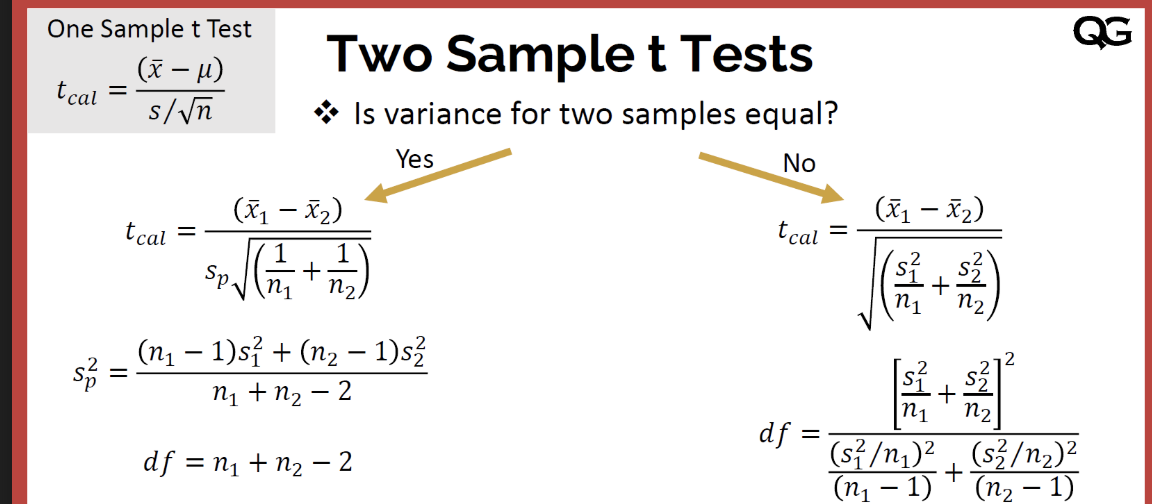

Manually:

In [ ]:
from scipy.stats import ttest_ind,t

In [ ]:
X = np.array([-1.75, -0.33, -1.26, 0.32, 1.53, 0.35, -0.96, -0.06, 0.42, -1.08])
Y = np.array([-0.29, 0.09, 1.70, -1.09, -0.44, -0.29, 0.25, -0.54, -1.38, 0.32])

In [ ]:
n = len(X)
m = len(Y)
X_hat = X.mean()
Y_hat = Y.mean()

In [ ]:
X_var = X.var(ddof=1)
Y_var = Y.var(ddof=1)

In [ ]:
#pool vairance
s_p = np.sqrt(((n-1) * X_var**2 + (m-1) * Y_var**2) / (n + m - 2))
s_p

np.float64(0.8607995585274839)

In [ ]:
T_stat = (X_hat - Y_hat) / (s_p * np.sqrt(1/n + 1/m))
T_stat

np.float64(-0.29873135373391996)

In [ ]:
df = n + m - 2
p_value = 2 * t.sf(abs(T_stat),df) # two tailed thats why multiply by 2
p_value

np.float64(0.7685663931031849)

In [ ]:
print('Rejected Null Hypothesis u_x != u_y' if p_value < alpha else "Not Rejected Null Hyphothesis u_x = u_y" )

Not Rejected Null Hyphothesis u_x = u_y


Using Library:

In [ ]:
X = np.array([-1.75, -0.33, -1.26, 0.32, 1.53, 0.35, -0.96, -0.06, 0.42, -1.08])
Y = np.array([-0.29, 0.09, 1.70, -1.09, -0.44, -0.29, 0.25, -0.54, -1.38, 0.32])
alpha = 0.05

In [ ]:
t_stat,p_value = ttest_ind(X,Y,equal_var=True)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")
print('Rejected Null Hypothesis u_x != u_y' if p_value < alpha else "Not Rejected Null Hyphothesis u_x = u_y" )

T-statistic: -0.2787
P-value: 0.7837
Not Rejected Null Hyphothesis u_x = u_y


# Problem 5 - 1:

In [ ]:
from sklearn.datasets import load_diabetes
from sklearn.metrics import median_absolute_error,mean_squared_error

In [ ]:
data = load_diabetes(as_frame=True)
df = data["frame"]
target = data["target"]

In [ ]:
df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0


In [ ]:
corrs = df.corr(numeric_only=True)["target"].drop('target')
corrs

,target
age,0.187889
sex,0.043062
bmi,0.586450
bp,0.441482
s1,0.212022
s2,0.174054
s3,-0.394789
s4,0.430453
s5,0.565883
s6,0.382483


In [ ]:
corrs = corrs.sort_values(key=abs,ascending=False)
corrs

,target
bmi,0.586450
s5,0.565883
bp,0.441482
s4,0.430453
s3,-0.394789
s6,0.382483
s1,0.212022
age,0.187889
s2,0.174054
sex,0.043062


In [ ]:
top_feature = corrs.index[0]
top_corr = corrs.iloc[0]
top_feature, top_corr

('bmi', np.float64(0.5864501344746885))

Problem 5 - 2

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error
from sklearn.model_selection import train_test_split

In [ ]:
X1 = df[[top_feature]]
y = target

In [ ]:
X1_train,X1_test,y_train,y_test = train_test_split(X1,y,test_size=0.2,random_state=42)

In [ ]:
model = LinearRegression()
model.fit(X1_train,y_train)
y_pred = model.predict(X1_test)

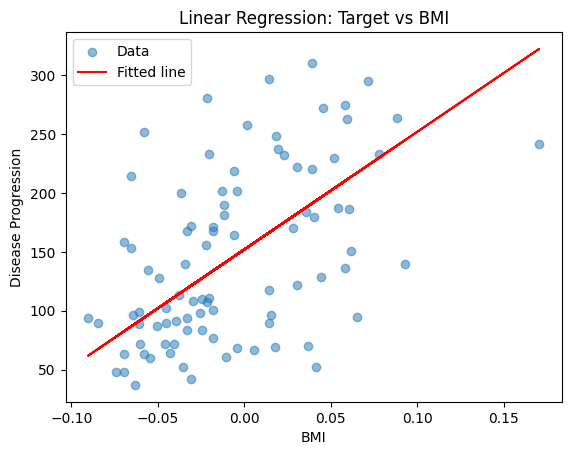

In [ ]:
plt.scatter(X1_test, y_test, alpha=0.5, label="Data")
plt.plot(X1_test, y_pred, color="red", label="Fitted line")
plt.xlabel("BMI")
plt.ylabel("Disease Progression")
plt.title("Linear Regression: Target vs BMI")
plt.legend()
plt.show()

In [ ]:
mse1 = mean_squared_error(y_test, y_pred)
mae1 = mean_absolute_error(y_test, y_pred)
print(f"MSE = {mse1}")
print(f"MAE = {mae1}")

MSE = 4061.8259284949268
MAE = 52.259976445345536


In [ ]:
X2 = np.log(df[[top_feature]] + 1e-6 - df[top_feature].min())
X2_train, X2_test,y_train,y_test = train_test_split(X2,y,test_size=0.2,random_state=42)

In [ ]:

model2 = LinearRegression()
model2.fit(X2_train,y_train)
y_pred2 = model2.predict(X2_test)

In [ ]:
mse2 = mean_squared_error(y_test,y_pred2)
mae2 = mean_absolute_error(y_test,y_pred2)
print(f"MSE with log = {mse2}")
print(f"MAE with log= {mae2}")

MSE with log = 8619.94406966433
MAE with log= 60.009611283634655


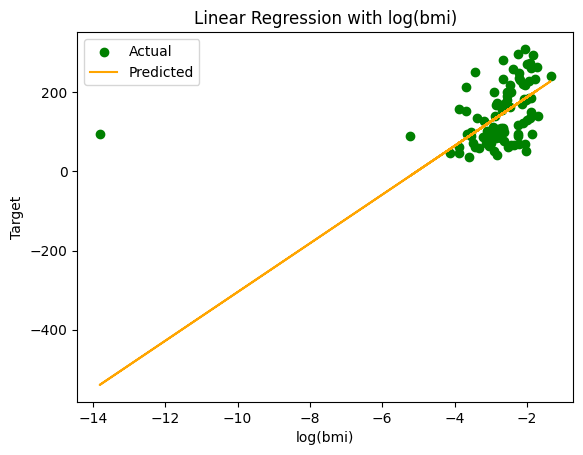

In [ ]:
plt.scatter(X2_test, y_test, color='green', label='Actual')
plt.plot(X2_test, y_pred2, color='orange', label='Predicted')
plt.title(f'Linear Regression with log({top_feature})')
plt.xlabel(f'log({top_feature})')
plt.ylabel('Target')
plt.legend()
plt.show()

In [ ]:
{
    "Top Feature": top_feature,
    "Correlation with Target": top_corr,
    "Original Feature MSE": mse1,
    "Original Feature MAE": mae1,
    "Log Feature MSE": mse2,
    "Log Feature MAE": mae2
}

{'Top Feature': 'bmi',
 'Correlation with Target': np.float64(0.5864501344746885),
 'Original Feature MSE': 4061.8259284949268,
 'Original Feature MAE': 52.259976445345536,
 'Log Feature MSE': 8619.94406966433,
 'Log Feature MAE': 60.009611283634655}

Problem 5 - 3:

In [ ]:
from itertools import combinations, chain
import statsmodels.api as sm

In [ ]:
def get_all_subsets(array):
    all_subsets = []
    for r in range(1, len(array) + 1):
        all_subsets.extend(combinations(array, r))
    return all_subsets

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(df.drop(columns = ['target']),y,test_size=0.2, random_state=42)

In [ ]:
X1_train = X_train[[top_feature]]
X1_test  = X_test[[top_feature]]

In [ ]:
lr1 = LinearRegression()
lr1.fit(X1_train, y_train)
y1_pred = lr1.predict(X1_test)

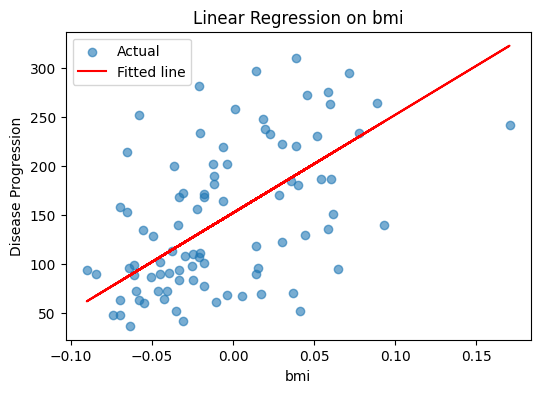

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(X1_test, y_test, alpha=0.6, label="Actual")
plt.plot(X1_test, y1_pred, color="red", label="Fitted line")
plt.xlabel(top_feature)
plt.ylabel("Disease Progression")
plt.title(f"Linear Regression on {top_feature}")
plt.legend()
plt.show()

In [ ]:
mse1 = mean_squared_error(y_test, y1_pred)
mae1 = mean_absolute_error(y_test, y1_pred)

print(f"Original {top_feature} → MSE: {mse1:.2f}, MAE: {mae1:.2f}")

Original bmi → MSE: 4061.83, MAE: 52.26


In [ ]:
min_val = df[top_feature].min()
shift   = 1e-6 - min_val
X2 = np.log(df[[top_feature]] + shift)

In [ ]:
X2_train = X2.loc[X1_train.index]
X2_test  = X2.loc[X1_test.index]

In [ ]:
lr2 = LinearRegression()
lr2.fit(X2_train, y_train)
y2_pred = lr2.predict(X2_test)

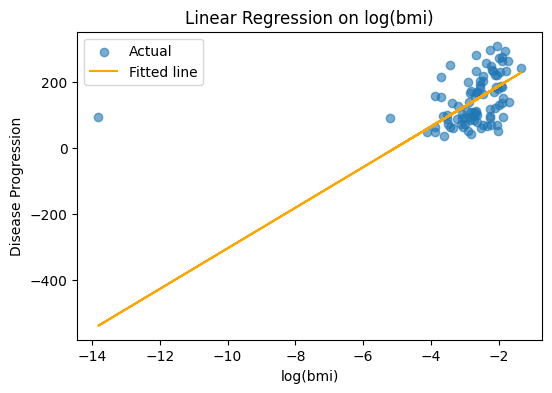

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(X2_test, y_test, alpha=0.6, label="Actual")
plt.plot(X2_test, y2_pred, color="orange", label="Fitted line")
plt.xlabel(f"log({top_feature})")
plt.ylabel("Disease Progression")
plt.title(f"Linear Regression on log({top_feature})")
plt.legend()
plt.show()

In [ ]:
mse2 = mean_squared_error(y_test, y2_pred)
mae2 = mean_absolute_error(y_test, y2_pred)

print(f"log({top_feature}) → MSE: {mse2:.2f}, MAE: {mae2:.2f}")


log(bmi) → MSE: 8619.94, MAE: 60.01


In [ ]:
feature_list = df.drop(columns=['target']).columns.tolist()
subsets = get_all_subsets(feature_list)

results = []
n_train = X_train.shape[0]

In [ ]:
for subset in subsets:
    X_train_sub = X_train[list(subset)]
    X_train_sub = sm.add_constant(X_train_sub)
    model = sm.OLS(y_train, X_train_sub).fit()
    aic = model.aic
    results.append({
        "features": subset,
        "aic": aic
    })

In [ ]:
best = min(results, key=lambda x: x["aic"])
best_features = list(best["features"])
print("Best AIC subset:", best_features, "AIC =", best["aic"])

Best AIC subset: ['sex', 'bmi', 'bp', 's1', 's2', 's5'] AIC = 3829.5239090754194


In [ ]:
X_test_best = X_test[best_features]
X_test_best = sm.add_constant(X_test_best)
y_test_pred = sm.OLS(y_train, sm.add_constant(X_train[best_features])).fit().predict(X_test_best)

In [ ]:
mse_best = mean_squared_error(y_test, y_test_pred)
mae_best = mean_absolute_error(y_test, y_test_pred)
print(f"Best-subset Model → MSE: {mse_best:.2f}, MAE: {mae_best:.2f}")

Best-subset Model → MSE: 2846.29, MAE: 42.61


# Problem 6

In [ ]:
from sklearn.datasets import load_wine
from scipy.stats import t, pearsonr

In [ ]:
data = load_wine(as_frame=True)
df = data["frame"]
X = df["color_intensity"]
y = df["hue"]

In [ ]:
X.head()

,color_intensity
0,5.64
1,4.38
2,5.68
3,7.80
4,4.32


In [ ]:
y.head()

,hue
0,1.04
1,1.05
2,1.03
3,0.86
4,1.04


In [ ]:
n = len(X)

In [ ]:
x_bar = np.mean(X)
y_bar = np.mean(y)

In [ ]:
numerator = np.sum((X - x_bar) * (y - y_bar))
denominator = np.sqrt(np.sum((X - x_bar)**2) * np.sum((y - y_bar)**2))

In [ ]:
rho = numerator / denominator

In [ ]:
T = rho * np.sqrt(n - 2) / np.sqrt(1 - rho**2)

In [ ]:
p_value = 2 * t.sf(np.abs(T), df=n - 2)

In [ ]:
print("Pearson correlation coefficient (ρ):", rho)
print("t-statistic:", T)
print("p-value:", p_value)

Pearson correlation coefficient (ρ): -0.5218131932287576
t-statistic: -8.115063490103632
p-value: 8.075008429978501e-14


In [ ]:
alpha = 0.05
if p_value < alpha:
    print("Reject H0 at α = 0.05")
else:
    print("Do not reject H0 at α = 0.05")

Reject H0 at α = 0.05


Using Library:

In [ ]:
rho_scipy, p_value_scipy = pearsonr(X, y)

In [ ]:
print(f"Pearson correlation coefficient (ρ) = {rho_scipy}")
print(f"p-value = {p_value_scipy}")

Pearson correlation coefficient (ρ) = -0.5218131932287576
p-value = 8.075008429978308e-14


In [ ]:
if p_value_scipy < alpha:
    print("Reject H0 at α = 0.05")
else:
    print("Do not reject H0 at α = 0.05")

Reject H0 at α = 0.05


# Problem 7

In [ ]:
from sklearn.datasets import load_linnerud
import pandas as pd

In [ ]:
data = load_linnerud(as_frame=True)
df = data["target"]

In [ ]:
data

{'data':     Chins  Situps  Jumps
 0     5.0   162.0   60.0
 1     2.0   110.0   60.0
 2    12.0   101.0  101.0
 3    12.0   105.0   37.0
 4    13.0   155.0   58.0
 5     4.0   101.0   42.0
 6     8.0   101.0   38.0
 7     6.0   125.0   40.0
 8    15.0   200.0   40.0
 9    17.0   251.0  250.0
 10   17.0   120.0   38.0
 11   13.0   210.0  115.0
 12   14.0   215.0  105.0
 13    1.0    50.0   50.0
 14    6.0    70.0   31.0
 15   12.0   210.0  120.0
 16    4.0    60.0   25.0
 17   11.0   230.0   80.0
 18   15.0   225.0   73.0
 19    2.0   110.0   43.0,
 'feature_names': ['Chins', 'Situps', 'Jumps'],
 'target':     Weight  Waist  Pulse
 0    191.0   36.0   50.0
 1    189.0   37.0   52.0
 2    193.0   38.0   58.0
 3    162.0   35.0   62.0
 4    189.0   35.0   46.0
 5    182.0   36.0   56.0
 6    211.0   38.0   56.0
 7    167.0   34.0   60.0
 8    176.0   31.0   74.0
 9    154.0   33.0   56.0
 10   169.0   34.0   50.0
 11   166.0   33.0   52.0
 12   154.0   34.0   64.0
 13   247.0   46.0   50

In [ ]:
data = load_linnerud(as_frame=True)
df = data["target"]

In [ ]:
X_cat = pd.qcut(df["Weight"], [0.0, 0.25, 0.5, 0.75, 1.0], labels=[0, 1, 2, 3])
Y_cat = pd.qcut(df["Waist"], [0.0, 0.25, 0.5, 0.75, 1.0], labels=[0, 1, 2, 3])

In [ ]:
obs = pd.concat([X_cat.rename("weight_bin"), Y_cat.rename("waist_bin")], axis=1)
obs_table = obs.groupby(["weight_bin", "waist_bin"]).size().unstack(fill_value=0)

<ipython-input-73-9edbf90a7c7b>:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_table = obs.groupby(["weight_bin", "waist_bin"]).size().unstack(fill_value=0)


In [ ]:
chi2_stat, pval, dof, expected = sts.chi2_contingency(obs_table)

In [ ]:
print("Contingency Table: \n", obs_table)
print("\nChi-Square Statistic:", chi2_stat)
print("Degrees of Freedom:", dof)
print("P-value:", pval)

Contingency Table: 
 waist_bin   0  1  2  3
weight_bin            
0           4  1  0  0
1           2  3  1  0
2           0  1  3  0
3           0  0  2  3

Chi-Square Statistic: 23.41111111111111
Degrees of Freedom: 9
P-value: 0.005336151061769739


In [ ]:
alpha = 0.05
print("\n" + ("Rejected" if pval < alpha else "Not Rejected"))


Rejected
